# Bayesian network search modelling

Goal: find best combination of activities to find a missing person, measured by maximizing probability of detection.

This version uses a model with a proper map, prior distribution, and geographic activities.

In [711]:
import pandas as pd
from math import prod
import random
pd.set_option('display.max_rows',20)
import time
import bn
import networkx as nx
import matplotlib.pyplot as plt
from shapely import Polygon, Point, union_all
from shapely.plotting import plot_polygon, plot_points

## Activities

Define the position of a bench

In [712]:
pos_bench = Point(0,0.27)

and relative to that, a set of search regions and activity types

In [713]:
footprints = {'north':Polygon([(-1,0),(1,0),(1,1),(-1,1)]),
              'south':Polygon([(-1,-1),(1,-1),(1,0),(-1,0)]),
              'path':Polygon([(-0.25,-1),(0,-1),(0.25,1),(0,1)]),
              'bench':pos_bench.buffer(0.25)
              }
activity_types = {'north':'mower','south':'mower','path':'flyby','bench':'circle'}

Key parameters:
* the number of activities (e.g. "search field")
* the maximum number of times each activity can be perforpartial
* proability of missing the person even though they are detectable, representing random error

In [714]:
activities = [k for k in footprints]
print(activities)
num_activities = len(activities)
max_tries = 3
prob_blink = 0.7 # 0.0 # 0.1 # 0.5 # 0.7


['north', 'south', 'path', 'bench']


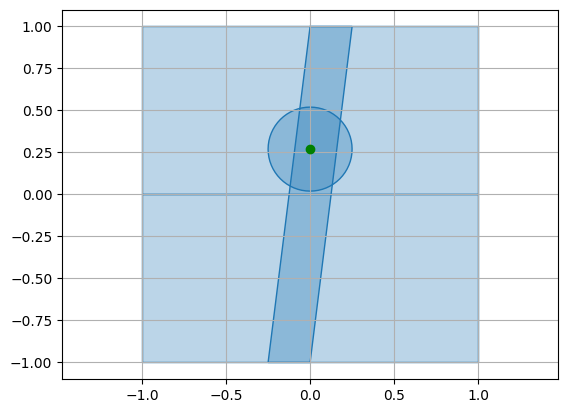

In [715]:
fig,ax = plt.subplots()
plot_points(pos_bench,color='g')
for a in activities:
    plot_polygon(footprints[a],ax=ax,add_points=False)
_= ax.axis('equal')

In [716]:
start_time = time.time()
print(start_time)

1778592528.5501275


## Global states

Define a global occlusion state, capturing some of the mutual dependence of detection events.
* 'open' means not occlused it all
* 'partial' means medium, perhaps occluded from just one direction of view
* 'strong' means strongly occluded, perhaps from all but a single direction, say stuck in a cave

Define a prior probability for each and set up as a proability distribution in a Pandas dataframe.

In [717]:
pdf_occ = pd.DataFrame({'occlusion':['open','partial','strong'],
                        'prob' : [0.8,0.1,0.1]})#
bn.validate_pdf(pdf_occ)
pdf_occ

,occlusion,prob
0,open,0.8
1,partial,0.1
2,strong,0.1


Similarly define a global appearance state, representing whether or not the person is going to blend in with the surroundings or stand out.

In [718]:
pdf_app = pd.DataFrame({'appearance':['blend','neutral','obvious'],
                        'prob' : [0.1,0.1,0.8]})
bn.validate_pdf(pdf_app)
pdf_app

,appearance,prob
0,blend,0.1
1,neutral,0.1
2,obvious,0.8


Finally define $2^{N_a}$ regions (where $N_a$ is the number of activities) representing the different overlaps between activities' respective footprints.

For example, `r1` has coverage `['a1', '~a2', '~a3', '~a4']` meaning is is that area covered only by activity `a1`, excluding any area covered by all other activities.

In [719]:
num_regions = 2**num_activities
coverage = {}
for i in range(num_regions):
    if i>0:
        coverage[f'r{i}'] = [a if 2**j & i > 0 else "~"+a for j,a in enumerate(activities) ]
regions = [r for r in coverage.keys()]
print(regions)
print(coverage)

['r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15']
{'r1': ['north', '~south', '~path', '~bench'], 'r2': ['~north', 'south', '~path', '~bench'], 'r3': ['north', 'south', '~path', '~bench'], 'r4': ['~north', '~south', 'path', '~bench'], 'r5': ['north', '~south', 'path', '~bench'], 'r6': ['~north', 'south', 'path', '~bench'], 'r7': ['north', 'south', 'path', '~bench'], 'r8': ['~north', '~south', '~path', 'bench'], 'r9': ['north', '~south', '~path', 'bench'], 'r10': ['~north', 'south', '~path', 'bench'], 'r11': ['north', 'south', '~path', 'bench'], 'r12': ['~north', '~south', 'path', 'bench'], 'r13': ['north', '~south', 'path', 'bench'], 'r14': ['~north', 'south', 'path', 'bench'], 'r15': ['north', 'south', 'path', 'bench']}


## Prior probability over regions

To get the prior, define a set of hypotheses for where the person is lost, a distribution over the footprints for each, and then combine.

First get the overall search domain and area.

Total search area: 4.0


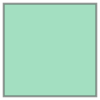

In [720]:
domain = union_all([footprints[a] for a in footprints])
domain_area = domain.area
print('Total search area:',domain_area)
domain

Using the footprints and the coverage combinations, get the geography for each region, then plot them all.

Note that several are empty as not all activities overlap.

In [721]:
region_polys = dict([(r,domain) for r in regions])
for r in regions:
    for a in activities:
        if a in coverage[r]:
            region_polys[r] = region_polys[r].intersection(footprints[a])
        else:
            region_polys[r] = region_polys[r].difference(footprints[a])
    if region_polys[r].area==0.0:
        # ensure anything empty is represented as an empty plot_polygon
        # get weird lines along shared boundaries otherwise
        region_polys[r] = Polygon(())
region_polys

{'r1': <MULTIPOLYGON (((1 0, 0.125 0, 0.132 0.058, 0.139 0.062, 0.159 0.077, 0.177 ...>,
 'r2': <MULTIPOLYGON (((-1 0, -0.125 0, -0.25 -1, -1 -1, -1 0)), ((1 -1, 0 -1, 0.12...>,
 'r3': <POLYGON EMPTY>,
 'r4': <POLYGON EMPTY>,
 'r5': <MULTIPOLYGON (((0.18 0.443, 0.177 0.447, 0.159 0.463, 0.139 0.478, 0.118 0....>,
 'r6': <POLYGON ((-0.125 0, 0.125 0, 0 -1, -0.25 -1, -0.125 0))>,
 'r7': <POLYGON EMPTY>,
 'r8': <POLYGON EMPTY>,
 'r9': <MULTIPOLYGON (((0.18 0.443, 0.193 0.429, 0.208 0.409, 0.22 0.388, 0.231 0.3...>,
 'r10': <POLYGON EMPTY>,
 'r11': <POLYGON EMPTY>,
 'r12': <POLYGON EMPTY>,
 'r13': <POLYGON ((0.132 0.058, 0.118 0.05, 0.096 0.039, 0.073 0.031, 0.049 0.025, 0...>,
 'r14': <POLYGON EMPTY>,
 'r15': <POLYGON EMPTY>}

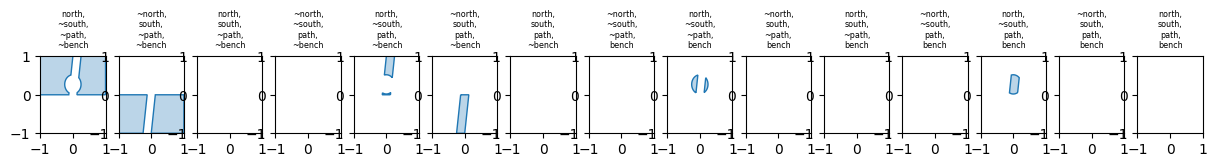

In [722]:
fig,ax = plt.subplots(ncols=num_regions-1,figsize=(15,1))
for i,r in enumerate(regions):
    plot_polygon(region_polys[r],ax=ax[i],add_points=False)
    ax[i].set_title(",\n".join(coverage[r]),fontsize='xx-small')
    _= ax[i].axis((-1,1,-1,1))

First hypothesis - they could be anywhere in the search domain.

In [723]:
cpdf_region_given_anywhere = pd.DataFrame({'region':regions,
                                           '|scenario':'anywhere',
                                           'prob':[region_polys[r].area/domain_area for r in regions]})
cpdf_region_given_anywhere

,region,|scenario,prob
0,r1,anywhere,0.417827
1,r2,anywhere,0.437500
2,r3,anywhere,0.000000
3,r4,anywhere,0.000000
4,r5,anywhere,0.033165
5,r6,anywhere,0.062500
6,r7,anywhere,0.000000
7,r8,anywhere,0.000000
8,r9,anywhere,0.019673
9,r10,anywhere,0.000000


Second hypothesis: they are somewhere along the path.

In [724]:
cpdf_region_given_path = pd.DataFrame({'region':regions,
                                           '|scenario':'path',
                                           'prob':[region_polys[r].area/footprints['path'].area if region_polys[r].intersection(footprints['path']).area>1e-9 else 0.0 for r in regions]})
cpdf_region_given_path

,region,|scenario,prob
0,r1,path,0.000000
1,r2,path,0.000000
2,r3,path,0.000000
3,r4,path,0.000000
4,r5,path,0.265316
5,r6,path,0.500000
6,r7,path,0.000000
7,r8,path,0.000000
8,r9,path,0.000000
9,r10,path,0.000000


Third hypothesis - they're on the bench.

In [725]:
cpdf_region_given_bench = pd.DataFrame({'region':regions,
                                           '|scenario':'bench',
                                           'prob':[1.0 if region_polys[r].contains(pos_bench) else 0.0 for r in regions]})
cpdf_region_given_bench

,region,|scenario,prob
0,r1,bench,0.0
1,r2,bench,0.0
2,r3,bench,0.0
3,r4,bench,0.0
4,r5,bench,0.0
5,r6,bench,0.0
6,r7,bench,0.0
7,r8,bench,0.0
8,r9,bench,0.0
9,r10,bench,0.0


Can combine these three into a single conditional distribution representation, having labeled each one with `|scenario`, just by stacking.

In [726]:
cpdf_region_given_scenario = pd.concat((cpdf_region_given_anywhere,cpdf_region_given_bench,cpdf_region_given_path))
bn.validate_cpdf(cpdf_region_given_scenario)
cpdf_region_given_scenario

,region,|scenario,prob
0,r1,anywhere,0.417827
1,r2,anywhere,0.437500
2,r3,anywhere,0.000000
3,r4,anywhere,0.000000
4,r5,anywhere,0.033165
...,...,...,...
10,r11,path,0.000000
11,r12,path,0.000000
12,r13,path,0.234684
13,r14,path,0.000000


Also define a prior over the scenarios, _i.e._ which we think are more likely.

In [727]:
scenarios = list(set(cpdf_region_given_scenario['|scenario']))
pdf_scenario = pd.DataFrame({'scenario':scenarios,'prob':[1/len(scenarios) for s in scenarios]}) # no idea
pdf_scenario = pd.DataFrame({'scenario':scenarios,'prob':[0.4,0.1,0.5]}) # strong prior that they're on bench or path
pdf_scenario

,scenario,prob
0,path,0.4
1,anywhere,0.1
2,bench,0.5


In [728]:
pdf_region_scenario = bn.joint_pdf_dependent(pdf_scenario,cpdf_region_given_scenario)
pdf_region = bn.get_marginal_pdf(pdf_region_scenario,of=['region'])
bn.validate_pdf(pdf_region)
pdf_region.sort_values('prob',ascending=False)


,region,prob
1,r13,0.596807
4,r6,0.206250
3,r5,0.109443
2,r2,0.043750
0,r1,0.041783
5,r9,0.001967


Visualize the region distribution as a heatmap.

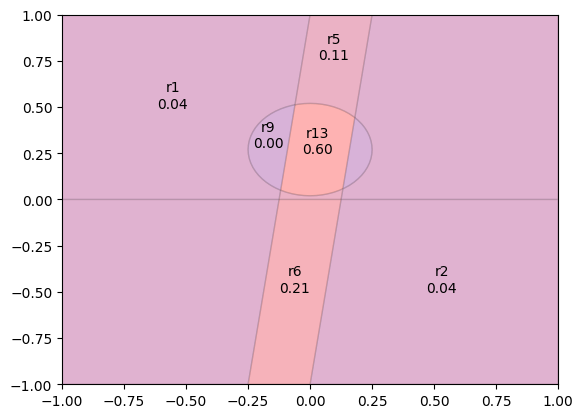

In [729]:
from math import tanh
fig,ax = plt.subplots()
for i,r in pdf_region.iterrows():
    this_region = r['region']
    this_xy = region_polys[this_region].representative_point()
    def color_scale(x):
        return 0.5*(1+tanh(5*x))
    this_color = (color_scale(r['prob']),0,1-color_scale(r['prob']))
    #print(this_color)
    plot_polygon(region_polys[this_region],ax=ax,add_points=False,color=this_color,edgecolor=(0,0,0,0.1))
    ax.annotate(f'{this_region}\n{r['prob']:.2f}',xy = (this_xy.x,this_xy.y),ha='center')
_= ax.axis((-1,1,-1,1))

Can combine these probabilities to get the joint distribution over the three global states

In [730]:
jpdf_global_states = bn.joint_pdf_independent(bn.joint_pdf_independent(pdf_app,pdf_occ),pdf_region)
bn.validate_pdf(jpdf_global_states)
jpdf_global_states

,appearance,occlusion,region,prob
0,blend,open,r1,0.003343
1,blend,open,r13,0.047745
2,blend,open,r2,0.003500
3,blend,open,r5,0.008755
4,blend,open,r6,0.016500
...,...,...,...,...
49,obvious,strong,r13,0.047745
50,obvious,strong,r2,0.003500
51,obvious,strong,r5,0.008755
52,obvious,strong,r6,0.016500


## Visibility models

Define the conditional probability of being indistinguishable in any given activity, given the appearance state

In [731]:
cpdf_indis_a_given_app = pd.DataFrame({'indis_a':[True,True,True,False,False,False],
                                       '|appearance':['blend','neutral','obvious','blend','neutral','obvious'],
                                       'prob' : [0.9,0.5,0.1,0.1,0.5,0.9]})
bn.validate_cpdf(cpdf_indis_a_given_app)
cpdf_indis_a_given_app

,indis_a,|appearance,prob
0,True,blend,0.9
1,True,neutral,0.5
2,True,obvious,0.1
3,False,blend,0.1
4,False,neutral,0.5
5,False,obvious,0.9


_Option: turn off distinguishability/blending_

In [732]:
turn_off_distinguishability = False
if turn_off_distinguishability:
    cpdf_indis_a_given_app = pd.DataFrame({'indis_a':[True,True,True,False,False,False],
                                        '|appearance':['blend','med','obvious','blend','partial','obvious'],
                                        'prob' : [0,0,0,1,1,1]})
    bn.validate_cpdf(cpdf_indis_a_given_app)
    cpdf_indis_a_given_app

For each activity type, we can define the conditional probability of occlusion to an activity of that type, given the global occlusion state.

In [733]:
cpdf_occ_a_given_occ = {'circle':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.5,0.3,0.1,0.5,0.7,0.9]}),
                        'mower':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.7,0.5,0.3,0.3,0.5,0.7]}),
                        'flyby':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                               '|occlusion':['strong','partial','open','strong','partial','open'],
                                               'prob' : [0.9,0.7,0.5,0.1,0.3,0.5]}),
}
for k in cpdf_occ_a_given_occ:
    bn.validate_cpdf(cpdf_occ_a_given_occ[k])
cpdf_occ_a_given_occ

{'circle':    occ_a |occlusion  prob
 0   True     strong   0.5
 1   True    partial   0.3
 2   True       open   0.1
 3  False     strong   0.5
 4  False    partial   0.7
 5  False       open   0.9,
 'mower':    occ_a |occlusion  prob
 0   True     strong   0.7
 1   True    partial   0.5
 2   True       open   0.3
 3  False     strong   0.3
 4  False    partial   0.5
 5  False       open   0.7,
 'flyby':    occ_a |occlusion  prob
 0   True     strong   0.9
 1   True    partial   0.7
 2   True       open   0.5
 3  False     strong   0.1
 4  False    partial   0.3
 5  False       open   0.5}

_Option: turn off occlusion altogether_

In [734]:
turn_off_occlusion = False
if turn_off_occlusion:
    cpdf_occ_a_given_occ = {'circle':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
                            'mower':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
                            'flyby':pd.DataFrame({'occ_a':[True,True,True,False,False,False],
                                                '|occlusion':['hard','med','open','hard','med','open'],
                                                'prob' : [0.,0.,0.,1.0,1.0,1.0]}),
    }
    for k in cpdf_occ_a_given_occ:
        bn.validate_cpdf(cpdf_occ_a_given_occ[k])
    cpdf_occ_a_given_occ

## Detection model

For each activity, use the conditional probabilities of occlusion and indistiguishability to find the joint distribution over all those events and the global states.

In [735]:
jpdf_model = jpdf_global_states
for a in activities:
    # extract the relevant conditional model of occlusion
    this_occ_cpdf = cpdf_occ_a_given_occ[activity_types[a]].rename(columns={'occ_a':'occ_'+a})
    jpdf_model = bn.joint_pdf_dependent(jpdf_model,this_occ_cpdf)
    # and of indistunguishability
    this_ind_cpdf = cpdf_indis_a_given_app.rename(columns={'indis_a':'indis_'+a})
    jpdf_model = bn.joint_pdf_dependent(jpdf_model,this_ind_cpdf)
bn.validate_pdf(jpdf_model)
jpdf_model

,indis_bench,occ_bench,indis_path,occ_path,indis_south,occ_south,indis_north,occ_north,appearance,occlusion,region,prob
0,True,True,True,True,True,True,True,True,blend,open,r1,9.868904e-06
1,True,True,True,True,True,True,True,True,blend,open,r13,1.409634e-04
2,True,True,True,True,True,True,True,True,blend,open,r2,1.033358e-05
3,True,True,True,True,True,True,True,True,blend,open,r5,2.584998e-05
4,True,True,True,True,True,True,True,True,blend,open,r6,4.871543e-05
...,...,...,...,...,...,...,...,...,...,...,...,...
13819,False,False,False,False,False,False,False,False,obvious,strong,r13,1.409634e-04
13820,False,False,False,False,False,False,False,False,obvious,strong,r2,1.033358e-05
13821,False,False,False,False,False,False,False,False,obvious,strong,r5,2.584998e-05
13822,False,False,False,False,False,False,False,False,obvious,strong,r6,4.871543e-05


Now determine the distribution of visibility, constructing on the go the conditional probability of visibility to each action given region, occlusion and indistinguishability.  The object is visible to activity _a_ if and only if it is not occluded from _a_, not indistinguishable to _a_, and lies in a region covered by _a_.

In [736]:
jpdf_model3 = jpdf_model
cpdf_vis_a = {}
for a in activities:
    print('Activity ',a)
    cpdf_vis_a[a] = pd.DataFrame({},columns=['vis_'+a,'|region','|occ_'+a,'|indis_'+a])
    for r in regions:
        for occ_a in [True,False]:
            for indis_a in [True,False]:
                prob_true = 0.0
                if occ_a==False:
                    if indis_a==False:
                        if a in coverage[r]:
                            prob_true = 1.0
                new_rows = pd.DataFrame({'vis_'+a:[True,False],
                                         'prob':[prob_true,1-prob_true]})
                new_rows['|occ_'+a] = occ_a
                new_rows['|indis_'+a] = indis_a
                new_rows['|region'] = r
                cpdf_vis_a[a] = pd.concat((cpdf_vis_a[a],new_rows))
    bn.validate_cpdf(cpdf_vis_a[a])
    print('Conditional distribution is ',cpdf_vis_a[a].shape)
    jpdf_model3 = bn.joint_pdf_dependent(jpdf_model3,cpdf_vis_a[a])
    print('Model is ', jpdf_model3.shape)          
bn.validate_pdf(jpdf_model3)
jpdf_model3

Activity  north
Conditional distribution is  (120, 5)
Model is  (13824, 13)
Activity  south
Conditional distribution is  (120, 5)
Model is  (13824, 14)
Activity  path
Conditional distribution is  (120, 5)
Model is  (13824, 15)
Activity  bench
Conditional distribution is  (120, 5)
Model is  (13824, 16)


,vis_bench,vis_path,vis_south,vis_north,indis_bench,occ_bench,indis_path,occ_path,indis_south,occ_south,indis_north,occ_north,appearance,occlusion,region,prob
360,True,True,False,True,False,False,False,False,True,True,False,False,blend,open,r13,4.060675e-06
362,True,True,False,True,False,False,False,False,True,True,False,False,blend,partial,r13,2.819913e-07
364,True,True,False,True,False,False,False,False,True,True,False,False,blend,strong,r13,5.639827e-08
366,True,True,False,True,False,False,False,False,True,True,False,False,neutral,open,r13,2.819913e-04
368,True,True,False,True,False,False,False,False,True,True,False,False,neutral,partial,r13,1.958273e-05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27638,False,False,False,False,False,False,False,False,False,False,False,True,neutral,partial,r1,1.370995e-06
27640,False,False,False,False,False,False,False,False,False,False,False,True,neutral,strong,r1,2.741989e-07
27642,False,False,False,False,False,False,False,False,False,False,False,True,obvious,open,r1,1.657976e-03
27644,False,False,False,False,False,False,False,False,False,False,False,True,obvious,partial,r1,1.151372e-04


Marginalize out the states for occlusion and indistinguishability for each activity - they have been used to determine the visibility states, and are nuisance variables for the rest.  This will shrink the model a lot.

In [737]:
jpdf_model3a = bn.get_marginal_pdf(jpdf_model3,['appearance','region','occlusion'] + ['vis_'+a for a in activities])
bn.validate_pdf(jpdf_model3a)
jpdf_model3a

,appearance,region,occlusion,vis_north,vis_south,vis_path,vis_bench,prob
0,blend,r1,open,False,False,False,False,0.003109
1,blend,r1,open,True,False,False,False,0.000234
2,blend,r1,partial,False,False,False,False,0.000397
3,blend,r1,partial,True,False,False,False,0.000021
4,blend,r1,strong,False,False,False,False,0.000405
...,...,...,...,...,...,...,...,...
211,obvious,r9,partial,True,False,False,True,0.000045
212,obvious,r9,strong,False,False,False,False,0.000063
213,obvious,r9,strong,False,False,False,True,0.000052
214,obvious,r9,strong,True,False,False,False,0.000023


To explore different policies, i.e. combnations of activities, introduce the numbers of times each activity is performed as additional variables.  We have to assign them proabilities, done with the following distribution, but of course these are fixed decisions, so they will be take out again later as conditional variables.

_This is necessary because the modeling utility can only combine a conditional probability into a joint, not two conditionals together.  Perhaps some future iteration would remove the need to do this._

In [738]:
num_tries = [i for i in range(max_tries+1)]
prob_tries = [1/len(num_tries) for i in num_tries]
pdf_tries = pd.DataFrame({'num_a':num_tries,
                          'prob': prob_tries})
bn.validate_pdf(pdf_tries)
pdf_tries

,num_a,prob
0,0,0.25
1,1,0.25
2,2,0.25
3,3,0.25


Using the random miss probability, construct a general conditional probability of detecting something by some activity given its visibility state and the number of tries.

In [739]:
cpdf_det_a_given_vis_a_num_a = pd.merge(pd.DataFrame({'det_a':[True,False]}),
                                        pd.DataFrame({'|vis_a':[True,False]}),how='cross')
cpdf_det_a_given_vis_a_num_a = pd.merge(cpdf_det_a_given_vis_a_num_a,
                                        pd.DataFrame({'|num_a':[i for i in range(max_tries+1)]}),how='cross')
cpdf_det_a_given_vis_a_num_a['prob'] = 0.0
def cond_prob_det(r,prob_blink=prob_blink):
    prob_true = 0.0
    if r['|vis_a']==True:
        if r['|num_a']>0:
            prob_true = (1-prob_blink**r['|num_a'])
    if r['det_a']==True:
        return prob_true
    else:
        return 1-prob_true
cpdf_det_a_given_vis_a_num_a['prob'] = cpdf_det_a_given_vis_a_num_a.apply(cond_prob_det,axis=1)
bn.validate_cpdf(cpdf_det_a_given_vis_a_num_a)
cpdf_det_a_given_vis_a_num_a

,det_a,|vis_a,|num_a,prob
0,True,True,0,0.000
1,True,True,1,0.300
2,True,True,2,0.510
3,True,True,3,0.657
4,True,False,0,0.000
5,True,False,1,0.000
6,True,False,2,0.000
7,True,False,3,0.000
8,False,True,0,1.000
9,False,True,1,0.700


Now use this activity by activity to determine the joint distribution over detection, attempts, visibility, and the global states.  This is where the model gets biggest.

In [740]:
jpdf_model4 = jpdf_model3a
for a in activities:
    this_tries_pdf = pdf_tries.rename(columns={'num_a':'num_'+a})
    jpdf_model4 = bn.joint_pdf_independent(jpdf_model4,this_tries_pdf)
    this_det_cpdf = cpdf_det_a_given_vis_a_num_a.rename(columns={'|num_a':'|num_'+a,
                                                                '|vis_a':'|vis_'+a,
                                                                'det_a':'det_'+a})
    jpdf_model4 = bn.joint_pdf_dependent(jpdf_model4,this_det_cpdf)
bn.validate_pdf(jpdf_model4)
jpdf_model4

,det_bench,det_path,det_south,det_north,appearance,region,occlusion,vis_north,vis_south,vis_path,vis_bench,num_north,num_south,num_path,num_bench,prob
1441,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,1,1.586201e-09
1442,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,2,2.696542e-09
1443,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,3,3.473781e-09
1445,True,True,False,True,blend,r13,open,True,False,True,True,1,0,2,1,2.696542e-09
1446,True,True,False,True,blend,r13,open,True,False,True,True,1,0,2,2,4.584122e-09
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190075,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,2,3,8.787941e-09
190076,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,0,2.562082e-08
190077,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,1,1.793457e-08
190078,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,2,1.255420e-08


Saving further proability modeling, we can identify those combinations with at least one detection using a simple logical "or" in the form of a summation.  Add a final column for the `det_any` state.

In [741]:
detect_cols = ['det_'+a for a in activities]
jpdf_model4['det_any']=jpdf_model4[detect_cols].sum(axis=1)>0
jpdf_model4

,det_bench,det_path,det_south,det_north,appearance,region,occlusion,vis_north,vis_south,vis_path,vis_bench,num_north,num_south,num_path,num_bench,prob,det_any
1441,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,1,1.586201e-09,True
1442,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,2,2.696542e-09,True
1443,True,True,False,True,blend,r13,open,True,False,True,True,1,0,1,3,3.473781e-09,True
1445,True,True,False,True,blend,r13,open,True,False,True,True,1,0,2,1,2.696542e-09,True
1446,True,True,False,True,blend,r13,open,True,False,True,True,1,0,2,2,4.584122e-09,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190075,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,2,3,8.787941e-09,False
190076,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,0,2.562082e-08,False
190077,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,1,1.793457e-08,False
190078,False,False,False,False,obvious,r9,strong,True,False,False,True,3,3,3,2,1.255420e-08,False


## Results

Process the table to get the probability of detection given the numbers of attempts of each activity.

In [742]:
summary_table = bn.get_conditional_pdf(jpdf_model4,of=['det_any'],given=['num_'+a for a in activities])
end_time = time.time()
print(f'Ran in {end_time - start_time:.1f} seconds')

Ran in 1.6 seconds


Just grab the rows where `det_any` was true and show the policies in order of descending probability.

_Also add the total number of activities, which will be needed later._

In [743]:
summary_table['num_total'] = sum([summary_table['|num_'+a] for a in activities])
summary_table = summary_table[summary_table['det_any']==True].drop('det_any',axis=1)
summary_table.sort_values(['prob'],ascending=[False])

,|num_north,|num_south,|num_path,|num_bench,prob,num_total
510,3,3,3,3,0.575460,12
494,3,2,3,3,0.561115,11
506,3,3,2,3,0.556164,11
446,2,3,3,3,0.549760,11
509,3,3,3,2,0.548422,11
...,...,...,...,...,...,...
319,1,0,0,0,0.112320,1
259,0,0,1,0,0.093951,1
303,0,3,0,0,0.081994,3
287,0,2,0,0,0.063648,2


Now just look at the best policy for each total number of scnearios, _e.g._ the best combination of six activities

In [744]:
summary_table.sort_values('prob').drop_duplicates(subset=['num_total'],keep='last')

,|num_north,|num_south,|num_path,|num_bench,prob,num_total
256,0,0,0,1,0.117695,1
320,1,0,0,1,0.209893,2
324,1,0,1,1,0.279638,3
325,1,0,1,2,0.339931,4
389,2,0,1,2,0.388689,5
393,2,0,2,2,0.427761,6
394,2,0,2,3,0.460618,7
410,2,1,2,3,0.491720,8
474,3,1,2,3,0.519153,9
490,3,2,2,3,0.540924,10


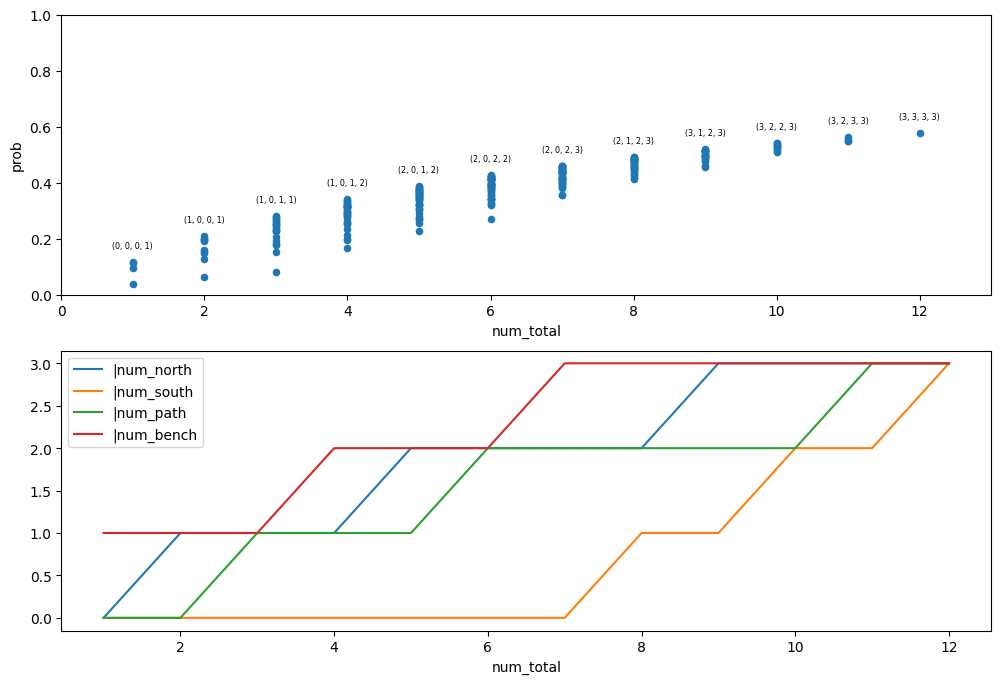

In [745]:
fig,ax=plt.subplots(nrows=2,figsize=(12,8))
summary_table.plot(x='num_total',y='prob',kind='scatter',ax=ax[0])
for i,r in summary_table.sort_values('prob').drop_duplicates(subset=['num_total'],keep='last').iterrows():
    ax[0].annotate(tuple([int(r['|num_'+a]) for a in activities]),
                xy = (r['num_total'],r['prob']+0.05),
                fontsize='xx-small',ha='center')
summary_table.sort_values('prob').drop_duplicates(subset=['num_total'],keep='last').plot(x='num_total',y=['|num_'+a for a in activities],kind='line',ax=ax[1])
_ = ax[0].axis([0,1+num_activities*max_tries,
                0,1])